In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import pandas as pd

from cnn_surgery.lenses.regressor_lens import get_regressor_lens, mse_mae
from cnn_surgery.utils.evaluate_per_class_accuracy import evaluate_classifier, load_testset_data
from cnn_surgery.utils.load_dataset import load_dataset
from cnn_surgery.utils.reconstruct_network import reconstruct_network

DATASET = "mnist"
METRICS_FILENAME = "metrics_merged.csv"

In [3]:
def test_network_accuracy(weights: np.ndarray | torch.Tensor, activation_fn):
    """
    Reconstructs a network from weights and activation function, evaluates it on the test set
    BEWARE: when using it in unlearning, the input could be a tensor, so be sure to convert it to numpy array first:
        weights = weights.detach().numpy()

    Returns:
        mean accuracy: float
        per class accuracies: list of floats
    """

    if isinstance(weights, torch.Tensor):
        weights = weights.detach().numpy()

    CNNModel = reconstruct_network(weights, activation_fn)
    # this returns a Keras model (Unterthiner code), we have to compile it first
    CNNModel.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    x_test, y_test = load_testset_data(DATASET)
    overall_acc, class_accs = evaluate_classifier(CNNModel, x_test, y_test)
    return overall_acc, class_accs

Loss functions

Load dataset and train model

In [ ]:
early = load_dataset('mnist', metrics_file='metrics_merged_mnist_early.csv', load_class_acc=True, stage='early')
middle = load_dataset('mnist', metrics_file='metrics_merged_mnist_middle.csv', load_class_acc=True, stage='middle')
final = load_dataset('mnist', metrics_file='metrics_merged.csv', load_class_acc=True, stage='final')

train_early, test_early, val_early = early
train_middle, test_middle, val_middle = middle
train_final, test_final, val_final = final

weights_train = np.concatenate([train_early[0], train_middle[0], train_final[0]])
weights_val = np.concatenate([val_early[0], val_middle[0], val_final[0]])
weights_test = np.concatenate([test_early[0], test_middle[0], test_final[0]])

accuracies_train = np.concatenate([train_early[1][:, -10:], train_middle[1][:, -10:], train_final[1][:, -10:]])
accuracies_val = np.concatenate([val_early[1][:, -10:], val_middle[1][:, -10:], val_final[1][:, -10:]])
accuracies_test = np.concatenate([test_early[1][:, -10:], test_middle[1][:, -10:], test_final[1][:, -10:]])

configs_train = pd.concat([train_early[2], train_middle[2], train_final[2]], ignore_index=True)
configs_val = pd.concat([val_early[2], val_middle[2], val_final[2]], ignore_index=True)
configs_test = pd.concat([test_early[2], test_middle[2], test_final[2]], ignore_index=True)

# all model indices are the same across training stages
assert all(train_early[2].index.map(lambda x: x.split('/')[-2]).values == train_middle[2].index.map(lambda x: x.split('/')[-2]).values)
assert all(train_early[2].index.map(lambda x: x.split('/')[-2]).values == train_final[2].index.map(lambda x: x.split('/')[-2]).values)

RegressorLens = get_regressor_lens(weights_train, accuracies_train, weights_val, accuracies_val, device='cpu')

In [107]:
# find the index of the best-performing model in the test set
overall_accuracies_test = np.concatenate([test_early[1][:, 0], test_middle[1][:, 0], test_final[1][:, 0]])
best_model_idx = np.argmax(overall_accuracies_test)
print(f"Best model index in test set: {best_model_idx}, accuracy: {overall_accuracies_test[best_model_idx]}")

MODEL_IDX = 16385  # you can change this to any index you want

Best model index in test set: 16384, accuracy: 0.9857000112533569


unlearning

In [ ]:
from jaxtyping import Float, Array

# ----- loss functions -----
simple_loss = lambda pred, target_idx: pred[target_idx]  # minimize the accuracy of the target class

def simple_loss(pred, target_idx):
    return pred[target_idx]  # minimize the accuracy of the target class

def unlearning_and_faithfulness_loss(pred, true, target_idx):  # needs a better name
    target_term = pred[target_idx]  # we want to minimize this

    # # set target index zero for this term by multiplying with a mask
    # mask = torch.ones_like(pred, requires_grad=False)
    # mask[target_idx] = 0
    # maintain_rest_term = (((true - pred) * mask) ** 2).mean()  # we want to maintain the accuracy of the other classes

    # mse = ((true - pred) ** 2).mean()  # we want the regressorlens to remain faithful to the actual performance
    # mae = (true - pred).abs().mean()

    # return target_term + mse
    return target_term #+ 3 * mae  # minimize predicted target performance

def boost_loss(pred, target_idx, beta=1.0):
    target_term = pred[target_idx]  # we want to minimize this

    # set target index zero for this term by multiplying with a mask
    mask = torch.ones_like(pred, requires_grad=False)
    mask[target_idx] = 0
    maintain_rest_term = beta * -1 * (pred * mask).sum()  # we want to increase or at least maintain the accuracy of the other classes

    return target_term + maintain_rest_term

def unlearning_metric(before_accs: Float[Array, 'n'], after_accs: Float[Array, 'n'], target_idx: int):

    target_term: float = min((after_accs[target_idx] - before_accs[target_idx]), 0)
    
    rest_before_accs = np.delete(before_accs, target_idx)
    rest_after_accs = np.delete(after_accs, target_idx)
    x = np.clip(rest_after_accs - rest_before_accs, a_min=None, a_max=0)
    maintain_rest_term = -1 * np.mean(x)
    return target_term + maintain_rest_term

In [ ]:
assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
input_weights: np.ndarray = weights_test[MODEL_IDX]
steps: int = 100
step_size: float = 10
target_class: int = 4
og_config: pd.Series = configs_test.iloc[MODEL_IDX]
beta = 1.0

"""
    input_weights: np.ndarray, weights of the model to be unlearned
    steps: int - number of optimization steps
    lens: torch.nn.Module - pretrained regressor lens model
    step_size: float - step size for the optimization
    target_class: int - class index to be unlearned
    og_config - original configuration of the model to be unlearned (for reconstructing the model)
"""

print("Starting unlearning procedure")
diffs_list = []
loss_list = []
target_term_list = []
# mse_term_list = []
mae_term_list = []
cosine_sim_list = []
metric_list = []
maintain_rest_list = []

before_accs = test_network_accuracy(input_weights, og_config["config.activation"])[1]

# convert input weights to tensor for optimization
doctored_input_weights = torch.tensor(input_weights, requires_grad=True, dtype=torch.float32)
RegressorLens.eval()

# optimize only the INPUT weights
for param in RegressorLens.parameters():
    param.requires_grad = False

for i in tqdm(range(steps), desc="Unlearning in progress"):
    
    # this is expensive: a new model needs to be reconstructed and evaluated at every step
    true = torch.tensor(
        test_network_accuracy(doctored_input_weights.detach().numpy(), og_config["config.activation"])[1],
        dtype=torch.float32,
    )

    pred: torch.Tensor = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze(0)  # forward pass
    loss = boost_loss(pred, target_class, beta=beta)
    loss.backward()  # compute gradients

    gradient = doctored_input_weights.grad.clone()
    if i == 0:
        first_gradient = gradient

    ### ACTUAL OPTIMIZATION STEP ###
    with torch.no_grad():
        doctored_input_weights -= step_size * gradient  # gradient step # type: ignore
        doctored_input_weights.grad.zero_()  # zero gradients # type:  ignore

    # -------- for analysis --------
    target_term: float = pred[target_class].item()
    # mse_term: float = ((true - pred) ** 2).mean().item()
    mae_term: float = (true - pred).abs().mean().item()
    mean_diff = abs((pred.detach().numpy() - np.array(true.detach().numpy()))).mean()
    metric = unlearning_metric(np.array(before_accs), true.detach().numpy(), target_class)
    mask = torch.ones_like(pred, requires_grad=False)
    mask[target_class] = 0
    maintain_rest_term = beta * -1 * (pred * mask).sum().item()

    loss_list.append(loss.item())
    target_term_list.append(target_term)
    # mse_term_list.append(mse_term)
    mae_term_list.append(mae_term)
    diffs_list.append(mean_diff)
    cosine_sim_list.append(np.dot(gradient, first_gradient) / (np.linalg.norm(gradient) * np.linalg.norm(first_gradient)))
    metric_list.append(metric)
    maintain_rest_list.append(maintain_rest_term)

Starting unlearning procedure


Unlearning in progress: 100%|██████████| 100/100 [00:45<00:00,  2.21it/s]


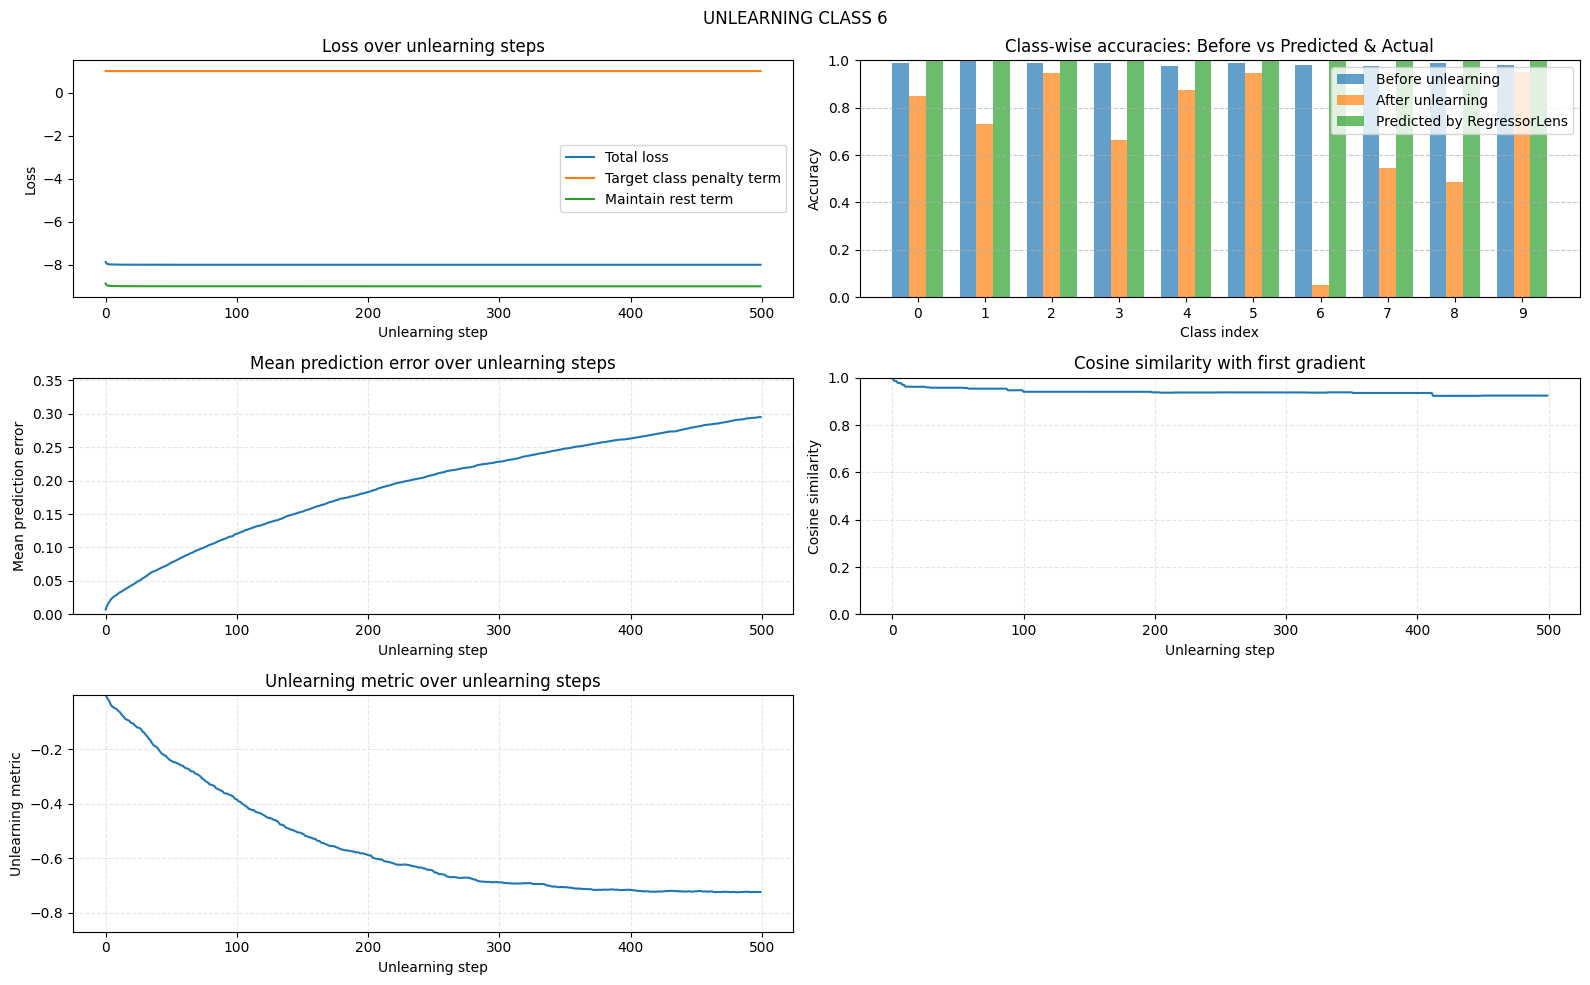

In [106]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(F"UNLEARNING CLASS {target_class}")

# ------- (0,0) loss plotting -------
ax = axes[0, 0]
ax.plot(loss_list, label="Total loss")
ax.plot(target_term_list, label="Target class penalty term")
ax.plot(maintain_rest_list, label="Maintain rest term")
# ax.plot(mse_term_list, label="MSE (RegressorLens faithfulness) term")
# ax.plot(mae_term_list, label="MAE (RegressorLens faithfulness) term")
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Loss")
ax.set_title("Loss over unlearning steps")
# ax.set_ylim(min(loss_list) * 1.2, max(loss_list) * 1.2)
ax.legend()

# ------- (0,1) accuracy -------
before_accs = accuracies_test[MODEL_IDX]
assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
preds = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze().detach().numpy()
actual_accs = test_network_accuracy(doctored_input_weights.detach().numpy(), configs_test.iloc[MODEL_IDX]["config.activation"])[1]

ax = axes[0, 1]
classes = np.arange(len(preds))
bar_width = 0.25
ax.bar(classes - bar_width, before_accs, width=bar_width, label="Before unlearning", alpha=0.7)
ax.bar(classes,              actual_accs, width=bar_width, label="After unlearning", alpha=0.7)
ax.bar(classes + bar_width,  preds,       width=bar_width, label="Predicted by RegressorLens", alpha=0.7)
ax.set_xlabel("Class index")
ax.set_ylabel("Accuracy")
ax.set_title("Class-wise accuracies: Before vs Predicted & Actual")
ax.set_xticks(classes)
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

# ------- (1,0) mean prediction error -------
ax = axes[1, 0]
ax.plot(diffs_list)
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Mean prediction error")
ax.set_title("Mean prediction error over unlearning steps")
ax.set_ylim(0, max(diffs_list) * 1.2 if len(diffs_list) else 1)
ax.grid(linestyle="--", alpha=0.3)

# ------- (1,1) gradient cosine similarity -------
ax = axes[1, 1]
ax.plot(cosine_sim_list)
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity with first gradient")
ax.set_ylim(0, 1)
ax.grid(linestyle="--", alpha=0.3)

# ------- (2,0) unlearning metric -------
ax = axes[2, 0]
ax.plot(metric_list)
ax.set_xlabel("Unlearning step")
ax.set_ylabel("Unlearning metric")
ax.set_title("Unlearning metric over unlearning steps")
ax.set_ylim(min(metric_list) * 1.2, max(metric_list) * 1.2)
ax.grid(linestyle="--", alpha=0.3)

# hide the (2,1) subplot (bottom right)
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
assert isinstance(RegressorLens, nn.Module), f"RegressorLens is not an instance of torch.nn.Module but {type(RegressorLens)}"
input_weights: np.ndarray = weights_test[MODEL_IDX]
steps: int = 200
step_size: float = 1.0
target_class: int = 5
og_config: pd.Series = configs_test.iloc[MODEL_IDX]

print("Starting unlearning procedure")
diffs_list = []
loss_list = []
target_term_list = []
mse_term_list = []
mae_term_list = []

# convert input weights to tensor for optimization
doctored_input_weights = torch.tensor(input_weights, requires_grad=True, dtype=torch.float32)

RegressorLens.eval()

# optimize only the INPUT weights
for param in RegressorLens.parameters():
    param.requires_grad = False

for i in tqdm(range(steps), desc="Unlearning in progress"):
    pred: torch.Tensor = RegressorLens(doctored_input_weights.unsqueeze(0)).squeeze(0)  # forward pass

    # this is expensive: a new model needs to be reconstructed and evaluated at every step
    true = torch.tensor(
        test_network_accuracy(doctored_input_weights.detach().numpy(), og_config["config.activation"])[1],
        dtype=torch.float32,
    )

    loss = unlearning_and_faithfulness_loss(pred, true, target_class)

    # for analysis
    target_term: float = pred[target_class].item()
    # mse_term: float = ((true - pred) ** 2).mean().item()
    mae_term: float = (true - pred).abs().mean().item()

    loss.backward()  # compute gradients
    gradients = doctored_input_weights.grad

    with torch.no_grad():
        doctored_input_weights -= step_size * gradients  # gradient step # type: ignore
        doctored_input_weights.grad.zero_()  # zero gradients # type: ignore

    mean_diff = abs((pred.detach().numpy() - np.array(true)).mean())

    loss_list.append(loss.item())
    target_term_list.append(target_term)
    # mse_term_list.append(mse_term)
    mae_term_list.append(mae_term)
    diffs_list.append(mean_diff)